In [1]:
# importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
### Create the Stacked LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

2025-03-28 13:49:28.487642: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# read stock data
data = pd.read_csv('/Users/mac/Downloads/ADNOC_Stock_historical_Data.csv')

In [4]:
# checking top 5 rows
df=data.copy()
df.head(5)

,Date,Open,High,Low,Close,Volume,Price_Change,Percentage_Change,Average_Price,Range
0,2024-05-30,3.33,3.36,3.31,3.32,9913413,-0.01,-0.300300,3.335,0.05
1,2024-05-29,3.39,3.41,3.32,3.32,9654434,-0.07,-2.064897,3.365,0.09
2,2024-05-28,3.48,3.50,3.38,3.38,16922020,-0.10,-2.873563,3.440,0.12
3,2024-05-27,3.52,3.54,3.48,3.48,7963633,-0.04,-1.136364,3.510,0.06
4,2024-05-24,3.50,3.55,3.50,3.52,11801280,0.02,0.571429,3.525,0.05


In [5]:
# checking shape of data
df.shape

(1288, 10)

In [6]:
# reseting index
df1=df.reset_index()['Close']

In [7]:
df1.head(5)

0    3.32
1    3.32
2    3.38
3    3.48
4    3.52
Name: Close, dtype: float64

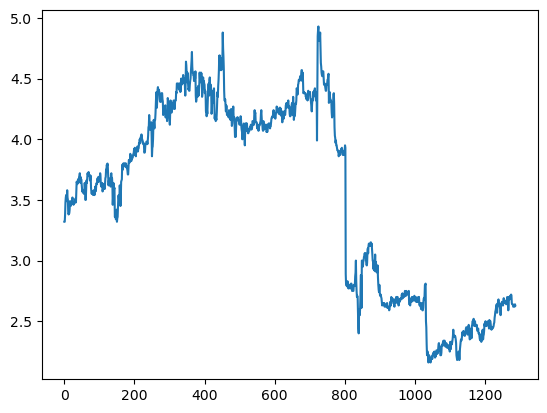

In [8]:
# checking on plot
plt.plot(df1); 

In [9]:
### LSTM are sensitive to the scale of the data. so we apply MinMax scaler 
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
df1=scaler.fit_transform(np.array(df1).reshape(-1,1))

In [10]:
print(df1)

[[0.41877256]
 [0.41877256]
 [0.44043321]
 ...
 [0.16606498]
 [0.1732852 ]
 [0.16967509]]


In [11]:
##splitting dataset into train and test split
training_size=int(len(df1)*0.65)
test_size=len(df1)-training_size
train_data,test_data=df1[0:training_size,:],df1[training_size:len(df1),:1]

In [12]:
training_size,test_size

(837, 451)

In [13]:
train_data

array([[0.41877256],
       [0.41877256],
       [0.44043321],
       [0.4765343 ],
       [0.49097473],
       [0.49819495],
       [0.4801444 ],
       [0.49097473],
       [0.51263538],
       [0.49097473],
       [0.48375451],
       [0.44404332],
       [0.44043321],
       [0.44404332],
       [0.44404332],
       [0.45487365],
       [0.4801444 ],
       [0.4765343 ],
       [0.46570397],
       [0.46931408],
       [0.47292419],
       [0.4801444 ],
       [0.4801444 ],
       [0.49097473],
       [0.4765343 ],
       [0.4765343 ],
       [0.46931408],
       [0.47292419],
       [0.47292419],
       [0.4765343 ],
       [0.4765343 ],
       [0.48736462],
       [0.48375451],
       [0.4765343 ],
       [0.50902527],
       [0.53790614],
       [0.53429603],
       [0.53068592],
       [0.53790614],
       [0.54512635],
       [0.53429603],
       [0.54151625],
       [0.55234657],
       [0.55595668],
       [0.5631769 ],
       [0.54873646],
       [0.55234657],
       [0.534

In [14]:
import numpy
# convert an array of values into a dataset matrix
def create_dataset(dataset, time_step=1):
	dataX, dataY = [], []
	for i in range(len(dataset)-time_step-1):
		a = dataset[i:(i+time_step), 0]   ###i=0, 0,1,2,3-----99   100 
		dataX.append(a)
		dataY.append(dataset[i + time_step, 0])
	return numpy.array(dataX), numpy.array(dataY)

In [15]:
# reshape into X=t,t+1,t+2,t+3 and Y=t+4
time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, ytest = create_dataset(test_data, time_step)

In [16]:
print(X_train.shape), print(y_train.shape)

(736, 100)
(736,)


(None, None)

In [17]:
print(X_test.shape), print(ytest.shape)

(350, 100)
(350,)


(None, None)

In [18]:
# reshape input to be [samples, time steps, features] which is required for LSTM
X_train =X_train.reshape(X_train.shape[0],X_train.shape[1] , 1)
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1] , 1)

In [19]:
model=Sequential()
model.add(LSTM(50,return_sequences=True,input_shape=(100,1)))
model.add(LSTM(50,return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error',optimizer='adam')


/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.fit(X_train,y_train,validation_data=(X_test,ytest),epochs=36,batch_size=64,verbose=1)

Epoch 1/36
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 267ms/step - loss: 0.3382 - val_loss: 0.0159
Epoch 2/36
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 215ms/step - loss: 0.0193 - val_loss: 0.0290
Epoch 3/36
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 222ms/step - loss: 0.0109 - val_loss: 0.0184
Epoch 4/36
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 211ms/step - loss: 0.0078 - val_loss: 0.0248
Epoch 5/36
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 183ms/step - loss: 0.0054 - val_loss: 0.0184
Epoch 6/36
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 193ms/step - loss: 0.0052 - val_loss: 0.0150
Epoch 7/36
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 187ms/step - loss: 0.0055 - val_loss: 0.0131
Epoch 8/36
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 182ms/step - loss: 0.0041 - val_loss: 0.0094
Epoch 9/36
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 183ms/step - loss: 0.0049 - val_loss: 0.0069
Epoch 10/36
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 206ms/step - loss: 0.0048 - val_loss: 0.0057
Epoch 11/36
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 210ms/step - loss: 0.0041 - val_loss: 0.0045
Epoch 12/36
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 182ms/step

In [22]:
### Lets Do the prediction and check performance metrics
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step


In [23]:
##Transformback to original form
train_predict=scaler.inverse_transform(train_predict)
test_predict=scaler.inverse_transform(test_predict)

In [24]:
### Calculate RMSE performance metrics
import math
from sklearn.metrics import mean_squared_error
math.sqrt(mean_squared_error(y_train,train_predict))

3.4680088882984115

In [25]:
### Test Data RMSE
math.sqrt(mean_squared_error(ytest,test_predict))

2.4590661190861023

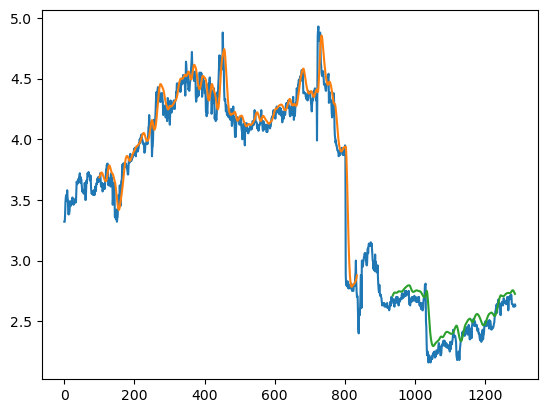

In [26]:
### Plotting 
# shift train predictions for plotting
look_back=100
trainPredictPlot = numpy.empty_like(df1)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict
# shift test predictions for plotting
testPredictPlot = numpy.empty_like(df1)
testPredictPlot[:, :] = numpy.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(df1)-1, :] = test_predict
# plot baseline and predictions
plt.plot(scaler.inverse_transform(df1))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()

In [27]:
len(test_data)

451

In [28]:
x_input=test_data[341:].reshape(1,-1)
x_input.shape


(1, 110)